# RLBench Unified HDF5 Verification

Visual checks on converted RLBench unified HDF5:
1. All 4 camera slots show real images from distinct viewpoints
2. 7D delta action trajectories are smooth
3. Norm stats are reasonable


In [5]:
import sys
sys.path.insert(0, "c:/Users/naqee/OneDrive/Desktop/CSC415 Project/RAEDiTRobotics")

import h5py
import numpy as np
import matplotlib.pyplot as plt
from data_pipeline.conversion.compute_norm_stats import load_norm_stats

DATA_DIR = "c:/Users/naqee/OneDrive/Desktop/CSC415 Project/data/unified/rlbench"
TASKS = ["close_jar", "open_drawer", "slide_block_to_color_target"]
SLOT_LABELS = ["front", "left_shoulder", "right_shoulder", "wrist"]
ACTION_LABELS = ["x", "y", "z", "qx", "qy", "qz", "qw", "gripper"]


## 1. Camera Slots — First Frame of demo_0 (all 3 tasks)

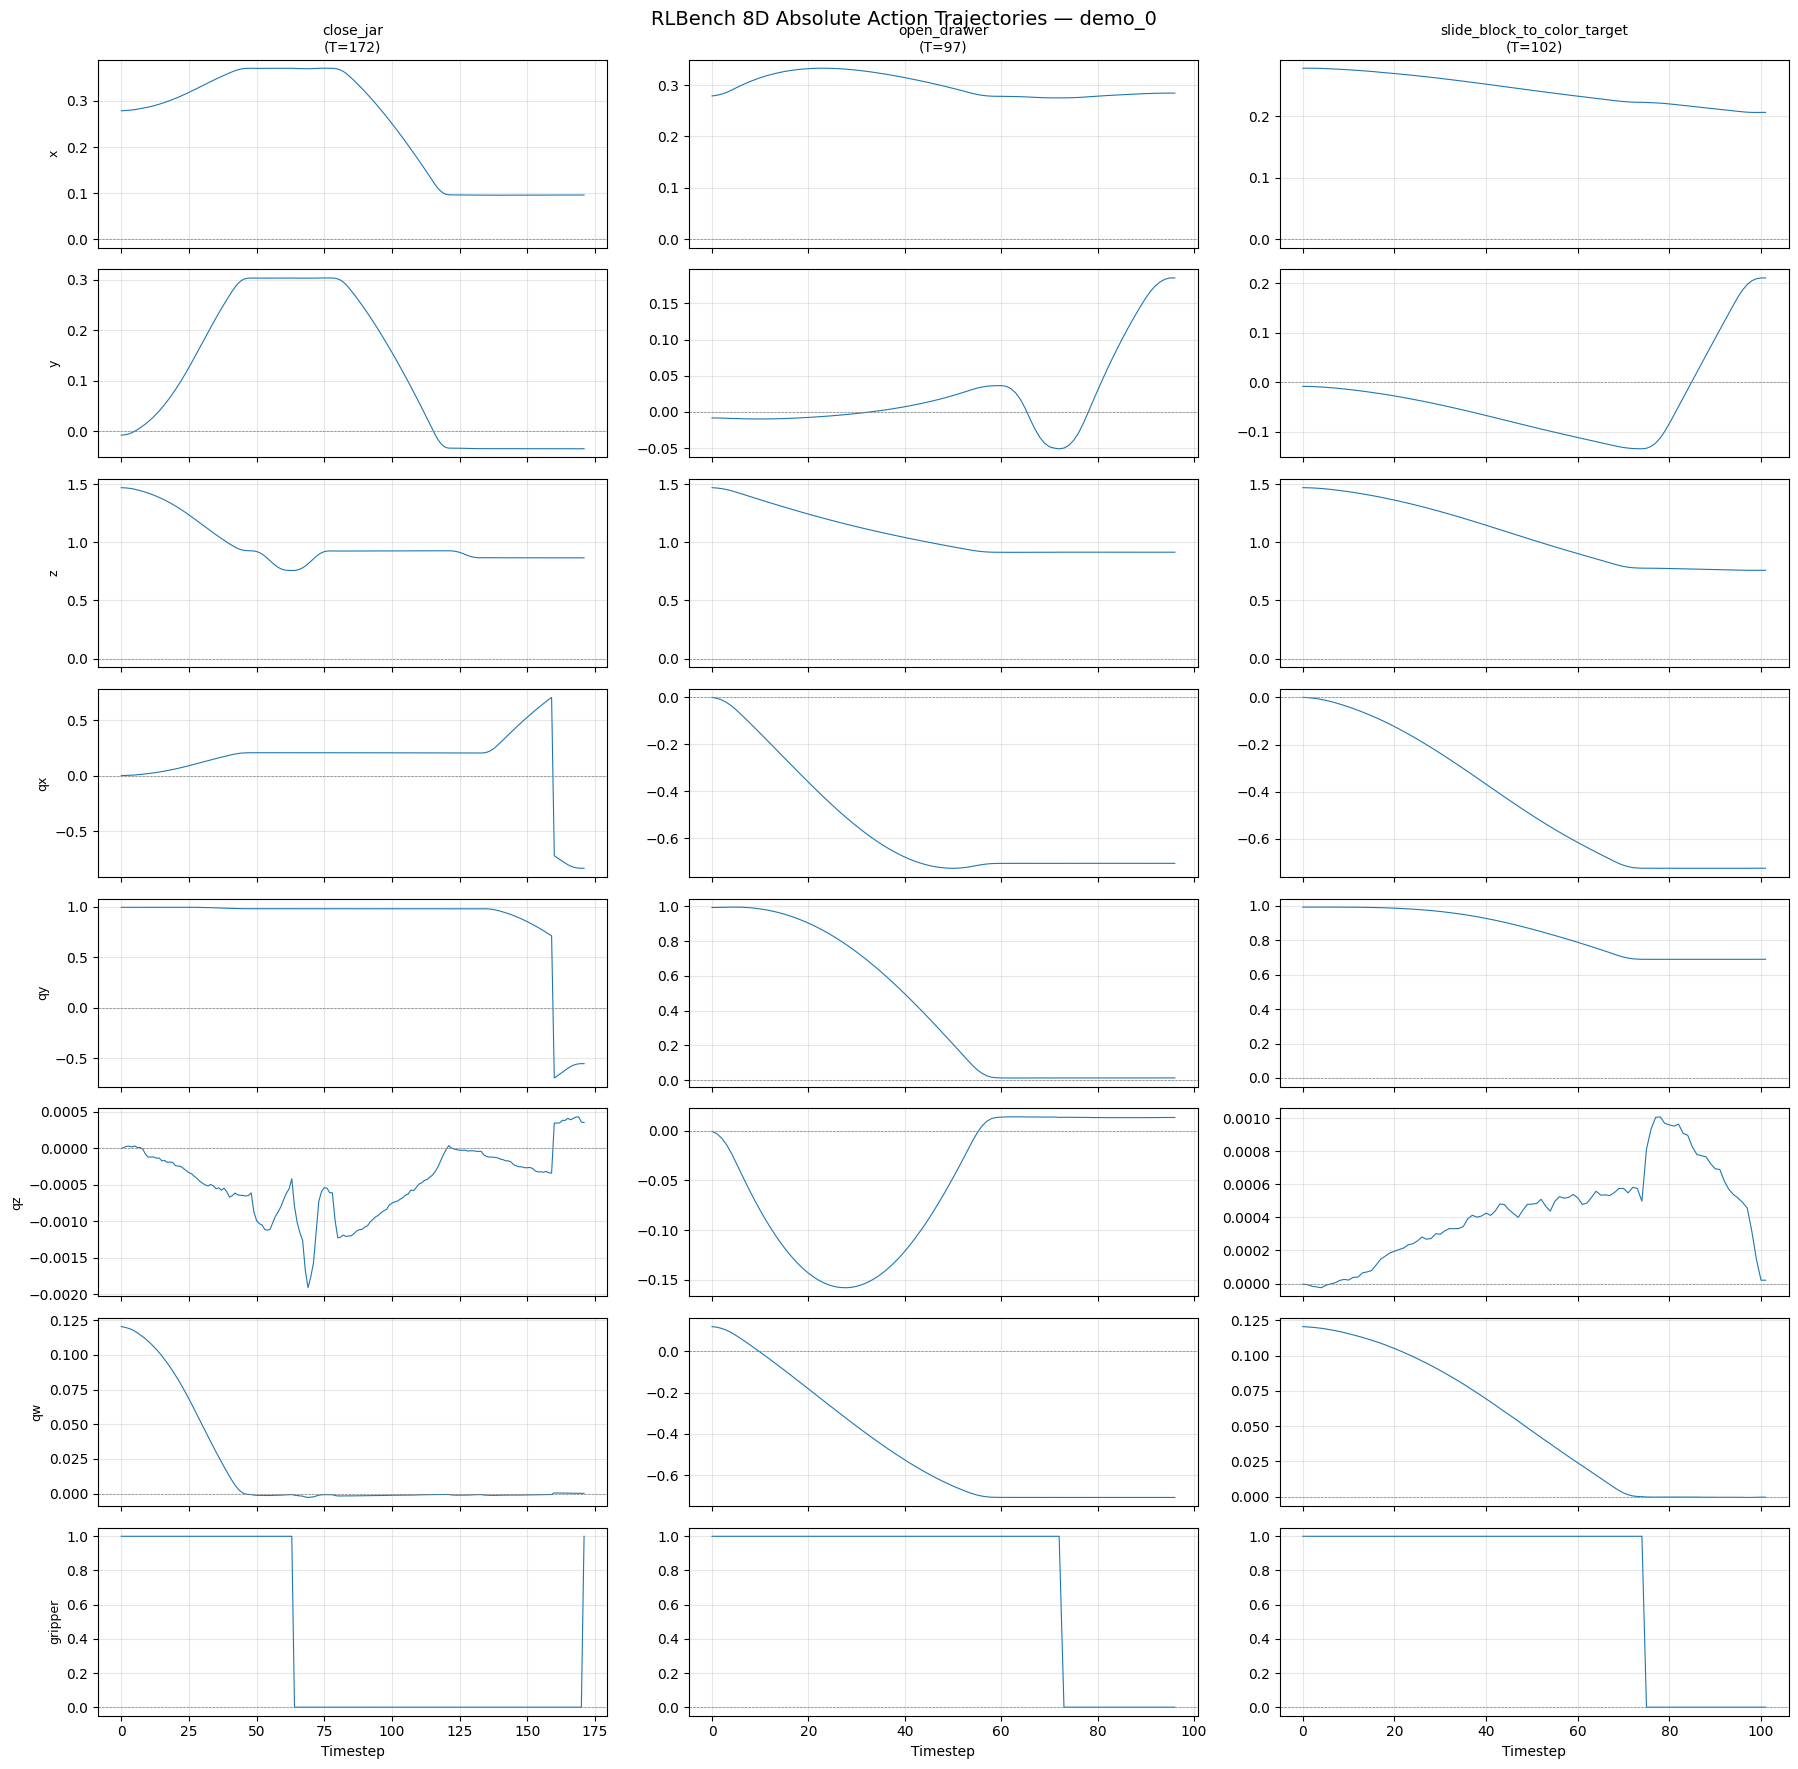

In [6]:
fig, axes = plt.subplots(8, 3, figsize=(18, 18), sharex="col")
for col, task in enumerate(TASKS):
    hdf5_path = f"{DATA_DIR}/{task}.hdf5"
    with h5py.File(hdf5_path, "r") as f:
        demo_key = list(f["data"].keys())[0]
        actions = f[f"data/{demo_key}/actions"][:]
    T = actions.shape[0]
    t = np.arange(T)
    for row in range(8):
        ax = axes[row, col]
        ax.plot(t, actions[:, row], linewidth=0.8)
        ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.set_ylabel(ACTION_LABELS[row], fontsize=9)
    axes[0, col].set_title(f"{task}\n(T={T})", fontsize=10)
    axes[7, col].set_xlabel("Timestep")
plt.suptitle("RLBench 8D Absolute Action Trajectories — demo_0", fontsize=14)
plt.tight_layout()
plt.show()


## 2. Action Trajectories — demo_0 (all 3 tasks)

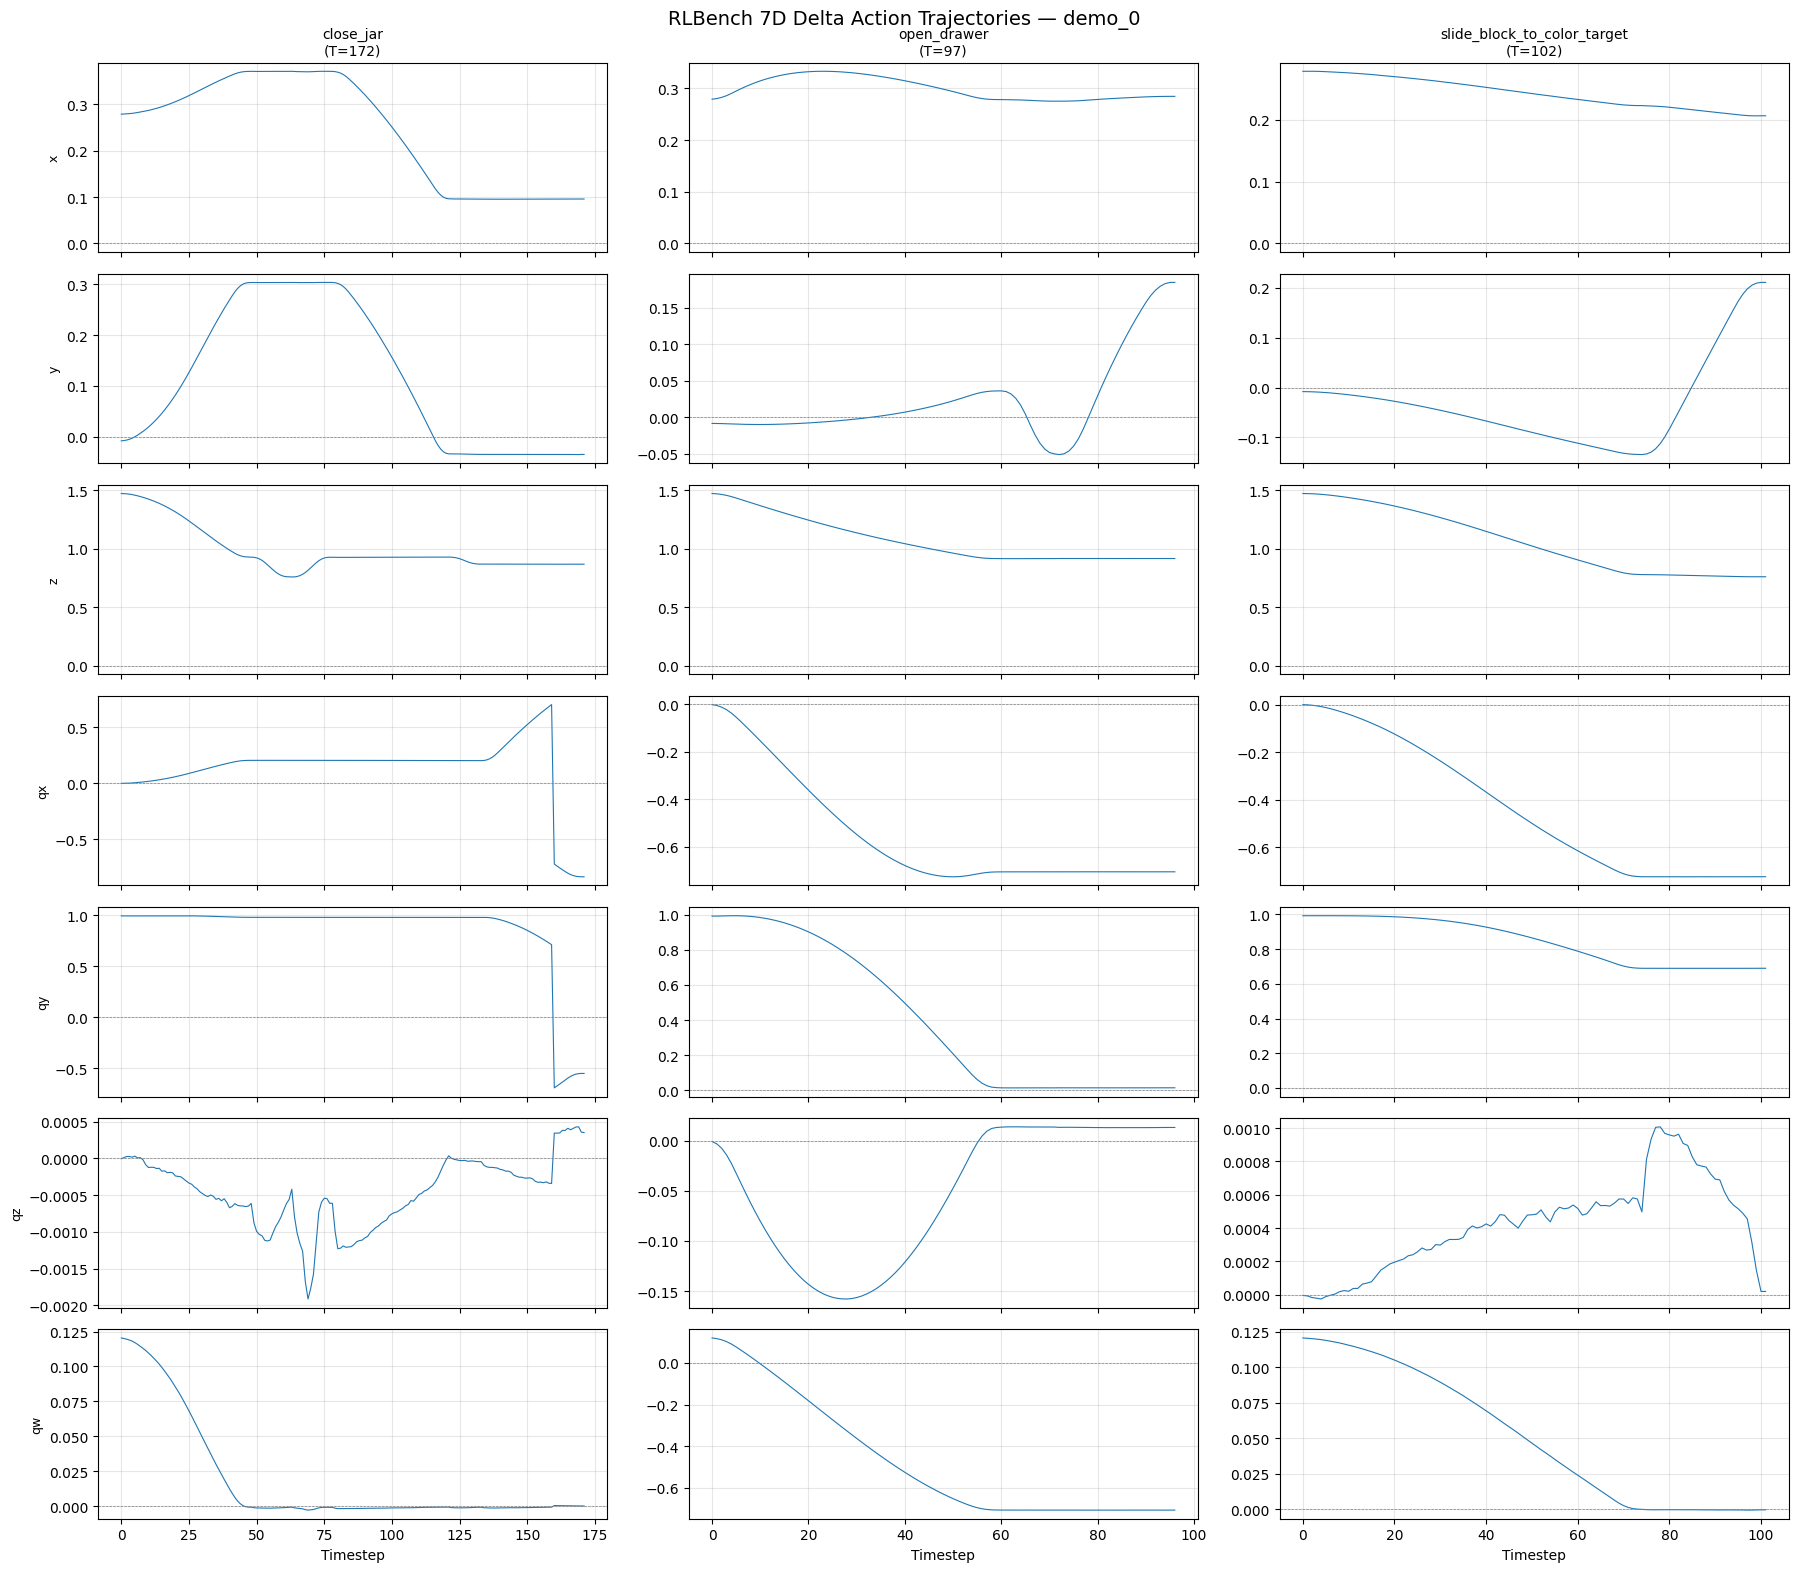

In [7]:
fig, axes = plt.subplots(7, 3, figsize=(18, 16), sharex="col")
for col, task in enumerate(TASKS):
    hdf5_path = f"{DATA_DIR}/{task}.hdf5"
    with h5py.File(hdf5_path, "r") as f:
        demo_key = list(f["data"].keys())[0]
        actions = f[f"data/{demo_key}/actions"][:]
    T = actions.shape[0]
    t = np.arange(T)
    for row in range(7):
        ax = axes[row, col]
        ax.plot(t, actions[:, row], linewidth=0.8)
        ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.set_ylabel(ACTION_LABELS[row], fontsize=9)
    axes[0, col].set_title(f"{task}\n(T={T})", fontsize=10)
    axes[6, col].set_xlabel("Timestep")
plt.suptitle("RLBench 7D Delta Action Trajectories — demo_0", fontsize=14)
plt.tight_layout()
plt.show()


## 3. Norm Stats Summary

In [8]:
for task in TASKS:
    hdf5_path = f"{DATA_DIR}/{task}.hdf5"
    stats = load_norm_stats(hdf5_path)
    print(f"--- {task} ---")
    print(f"  Action mean:  {np.round(stats['actions']['mean'], 5)}")
    print(f"  Action std:   {np.round(stats['actions']['std'], 5)}")
    print(f"  Action min:   {np.round(stats['actions']['min'], 5)}")
    print(f"  Action max:   {np.round(stats['actions']['max'], 5)}")
    print(f"  Proprio mean: {np.round(stats['proprio']['mean'], 5)}")
    print(f"  Proprio std:  {np.round(stats['proprio']['std'], 5)}")
    print()


--- close_jar ---
  Action mean:  [ 2.6952e-01  7.3550e-02  9.8662e-01 -2.7900e-03  9.0120e-01 -3.2000e-04
  1.9850e-02  4.1788e-01]
  Action std:   [0.10264 0.15973 0.19849 0.31241 0.29698 0.01002 0.03933 0.49321]
  Action min:   [-0.06964 -0.33881  0.75803 -0.89803 -0.70663 -0.12415 -0.07325  0.     ]
  Action max:   [0.47345 0.40301 1.47164 0.74221 1.      0.16036 0.12067 1.     ]
  Proprio mean: [ 0.13109  0.27625  0.02359 -1.98965 -0.01661  2.2361   1.05657  0.41788]
  Proprio std:  [0.29412 0.32884 0.25126 0.52739 0.13692 0.42045 0.54515 0.49321]

--- open_drawer ---
  Action mean:  [ 0.26131  0.0901   1.15909 -0.58642  0.37347 -0.05703 -0.46031  0.73446]
  Action std:   [0.06542 0.09683 0.15621 0.22275 0.40354 0.06723 0.2907  0.44163]
  Action min:   [ 0.00275 -0.05947  0.91121 -0.89406 -0.18893 -0.37081 -0.71025  0.     ]
  Action max:   [0.39408 0.4614  1.6873  0.00367 0.99575 0.09844 0.40857 1.     ]
  Proprio mean: [ 0.42142  0.46031  0.04735 -1.50375 -0.76864  1.13601 -0.81